# Feature Engineering Notebook

This notebook runs the feature engineering pipeline and explores the generated features.

In [1]:
# 1. Setup and imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure local source takes precedence
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

from b2b_credit_risk_analysis.features.panel_features import build_customer_exposure_features
from b2b_credit_risk_analysis.features.risk_features import build_default_label

sns.set(style="whitegrid")

In [3]:
# 2. Run feature engineering pipeline
input_dir = "data/processed/phase2"
output_dir = "data/processed/features"

input_path = project_root / input_dir
output_path = project_root / output_dir
output_path.mkdir(parents=True, exist_ok=True)

fact_exposure_snapshot = pd.read_csv(input_path / "fact_exposure_snapshot.csv")
fact_default_event = pd.read_csv(input_path / "fact_default_event.csv")

print("Loaded data:")
print(f"fact_exposure_snapshot: {fact_exposure_snapshot.shape}")
print(f"fact_default_event: {fact_default_event.shape}")

customer_features = build_customer_exposure_features(fact_exposure_snapshot)
target_label = build_default_label(fact_exposure_snapshot, fact_default_event)

dataset = customer_features.merge(target_label, on="customer_key", how="left")
dataset["has_default"] = dataset["has_default"].fillna(0).astype(int)

print(f"Final dataset: {dataset.shape}")
print(dataset.head())

Loaded data:
fact_exposure_snapshot: (384221, 20)
fact_default_event: (8011, 9)
Final dataset: (10000, 8)
   customer_key  total_exposure  total_overdue  avg_utilization  max_overdue  \
0             1    5.098456e+08   1.062024e+08         0.694239   4833970.35   
1             2    9.325729e+08   1.026136e+08         0.452623   4016365.14   
2             3    3.460612e+06   4.316011e+05         0.435602     24508.37   
3             4    2.246920e+06   5.028745e+05         1.213359     18808.46   
4             5    2.650903e+07   3.794258e+06         1.091009    220576.70   

   monthly_obs  overdue_rate  has_default  
0           33      0.208303            1  
1           48      0.110033            0  
2           41      0.124718            1  
3           41      0.223806            1  
4           34      0.143131            1  


In [4]:
# 3. Save features
dataset_path = output_path / "customer_feature_dataset.csv"
dataset.to_csv(dataset_path, index=False)
print(f"Saved features to {dataset_path}")

Saved features to /Users/huseyn/Documents/GitHub/b2b_credit_risk_analysis/data/processed/features/customer_feature_dataset.csv


       customer_key  total_exposure  total_overdue  avg_utilization  \
count   10000.00000    1.000000e+04   1.000000e+04     10000.000000   
mean     5000.50000    1.437512e+08   1.942851e+07         0.670841   
std      2886.89568    4.029421e+08   5.776783e+07         0.291084   
min         1.00000    1.257642e+05   1.119615e+04         0.121903   
25%      2500.75000    4.649371e+06   7.022732e+05         0.439922   
50%      5000.50000    1.858376e+07   2.703113e+06         0.612986   
75%      7500.25000    7.682762e+07   1.071885e+07         0.903265   
max     10000.00000    5.485851e+09   1.291918e+09         1.247190   

        max_overdue   monthly_obs  overdue_rate   has_default  
count  1.000000e+04  10000.000000  10000.000000  10000.000000  
mean   1.042781e+06     38.422100      0.147347      0.801100  
std    2.969834e+06     13.146209      0.045200      0.399193  
min    1.950480e+03      7.000000      0.061797      0.000000  
25%    3.995903e+04     29.000000      0

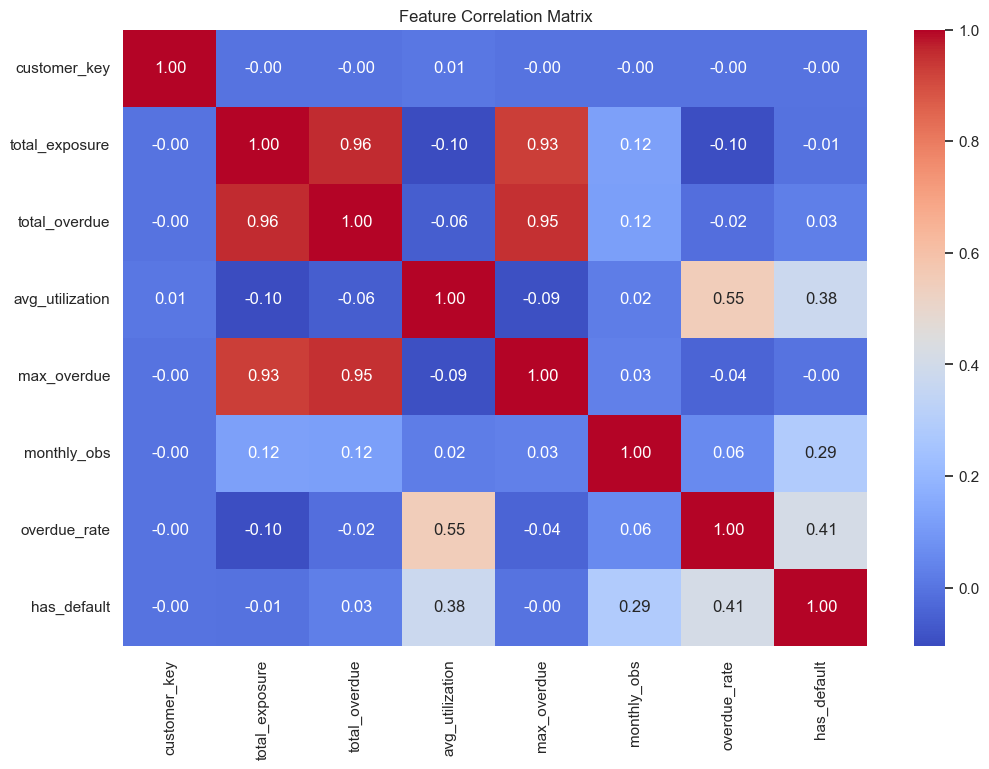

In [5]:
# 4. Feature exploration
print(dataset.describe())

# Distribution of target
print(dataset['has_default'].value_counts())

# Correlation heatmap
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
corr_matrix = dataset[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()